In [13]:
%pwd
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [14]:
from scripts.run_experiments import run_experiment
from scripts.experiment_utils import generate_experiments

In [15]:
base_config = {
    # Experiment
    "experiment": "clelia_curve",
    "random_seed": 42,
    "logging": True,

    # Dataset
    "dataset_name": "clelia_curve",
    "batch_size": 64,
    "rotation": "random",
    "translation": None,
    "n_times": 10000,
    "radius": 2.0,
    "embedding_dim": 10,
    "noise_var": 0.001,
    "clelia_c": 1,

    # Model
    'model_type': 'EuclideanVAE',
    "data_dim": 10,
    'latent_dim': 2,
    'sftbeta': 4.5,
    'device': "cpu",
    'encoder_widths': [50, 50, 50],
    'decoder_widths': [50, 50, 50],

    # Optimizer
    "learning_rate": 0.001,

    # Trainer
    'verbose': False,
    'num_epochs': 15,
    'log_interval': 100,
    'recon_loss': "MSE",
    'topo_loss': True,
    'dim_topo_loss': 0,
    'alpha': 1.0,  # Weight for reconstruction loss
    'beta': 0.0,  # Weight for KL loss
    'gamma': 0.0,  # Weight for topological loss

    # Curvature computation
    "compute_true_curv": True,
    "compute_learned_curv": False,
    "compute_rec_curv": True,
    "quadric_dim": 1,
    "n_plot_points": 1000,
    "n_points_emp_curv": 800,
    "n_points_pullback_curv": 800, 
    "k": 160,
    "smoothing": False,
    
    # Persistent homology
    "persistent_homology": False,
    "n_points_pers_hom": 1000,
    "scale": False,
    "homology_dimensions": [0, 1]
}

param_grid = {
    "wiggling_dim": [4] * 14,
    "embedding_dim": [10] * 14,
    "alpha": [1] * 2 + [1, 1, 1, 0] * 3,
    "gamma": [0] * 2 + [1, 100, 1000, 1] * 3,
    "clelia_c": [0.3] * 14,
    "dim_topo_loss": [0] + [1] + [0] * 4 + [1] * 4 + [2] * 4,
}

# param_grid = {
#     "alpha": [1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0] * 3,
#     "gamma": [0.0, 1.0, 1.0, 100.0, 100.0, 1.0, 1.0] * 3,
#     "dim_topo_loss": ["_", 0, 1, 0, 1, 0, 1] * 3,
#     "clelia_c": [0.3] * 7 + [1.0] * 7 + [3.0] * 7
# }

all_configs = generate_experiments(base_config, param_grid)


Running exp00_clelia_curve. 
Description: wiggling_dim=4, embedding_dim=10, alpha=1, gamma=0, clelia_c=0.3, dim_topo_loss=0
--------------------------------------------------------------------------------------


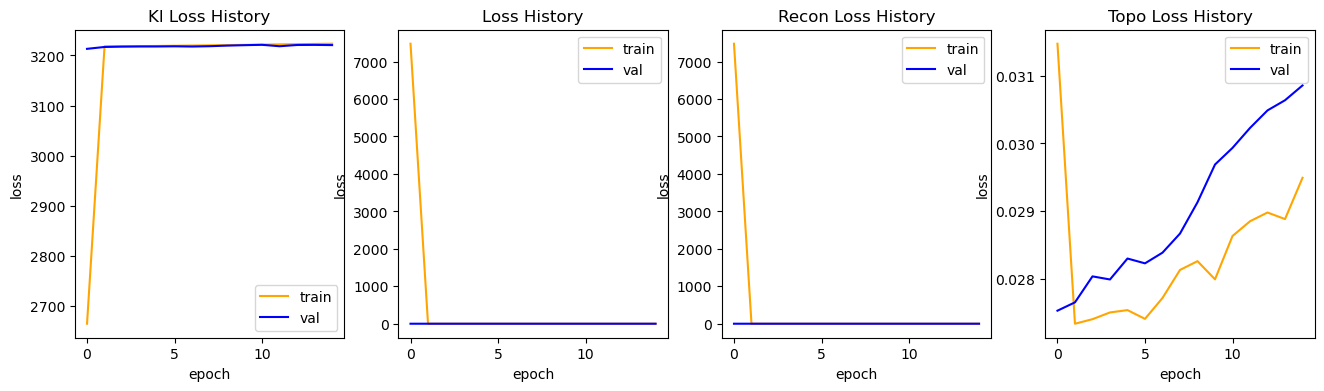

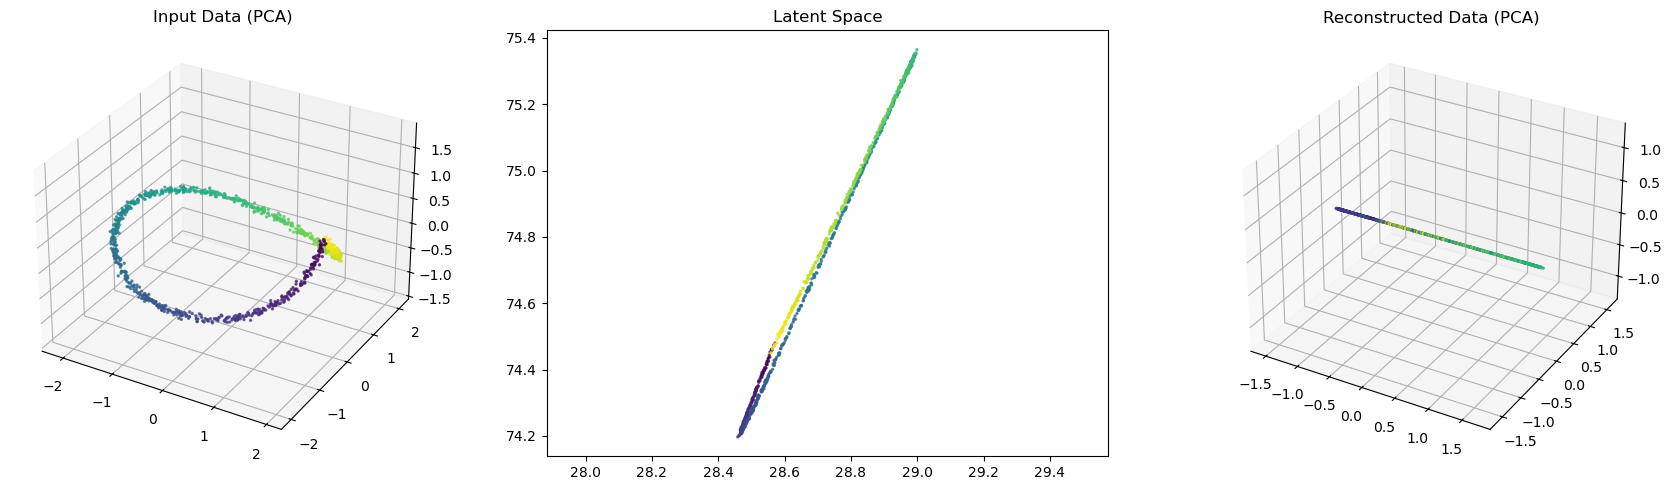

Estimating 1D curvature: 100%|██████████| 800/800 [00:00<00:00, 963.99it/s] 


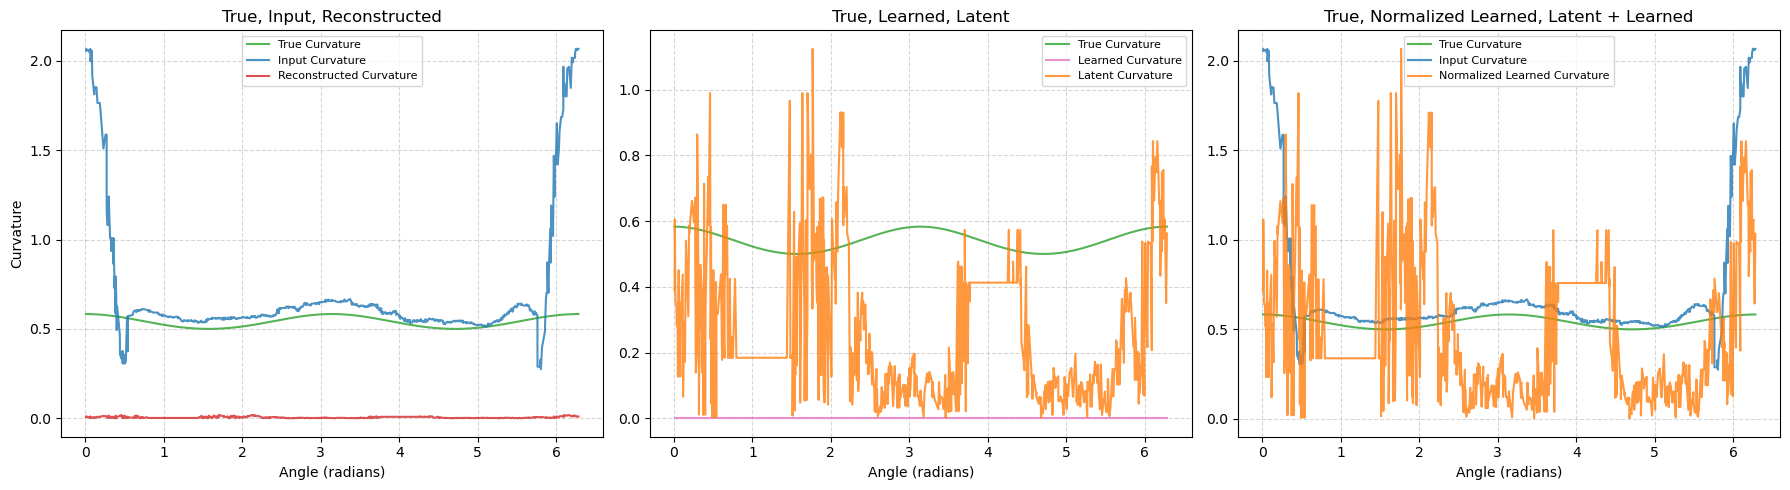

<Figure size 1800x1000 with 0 Axes>

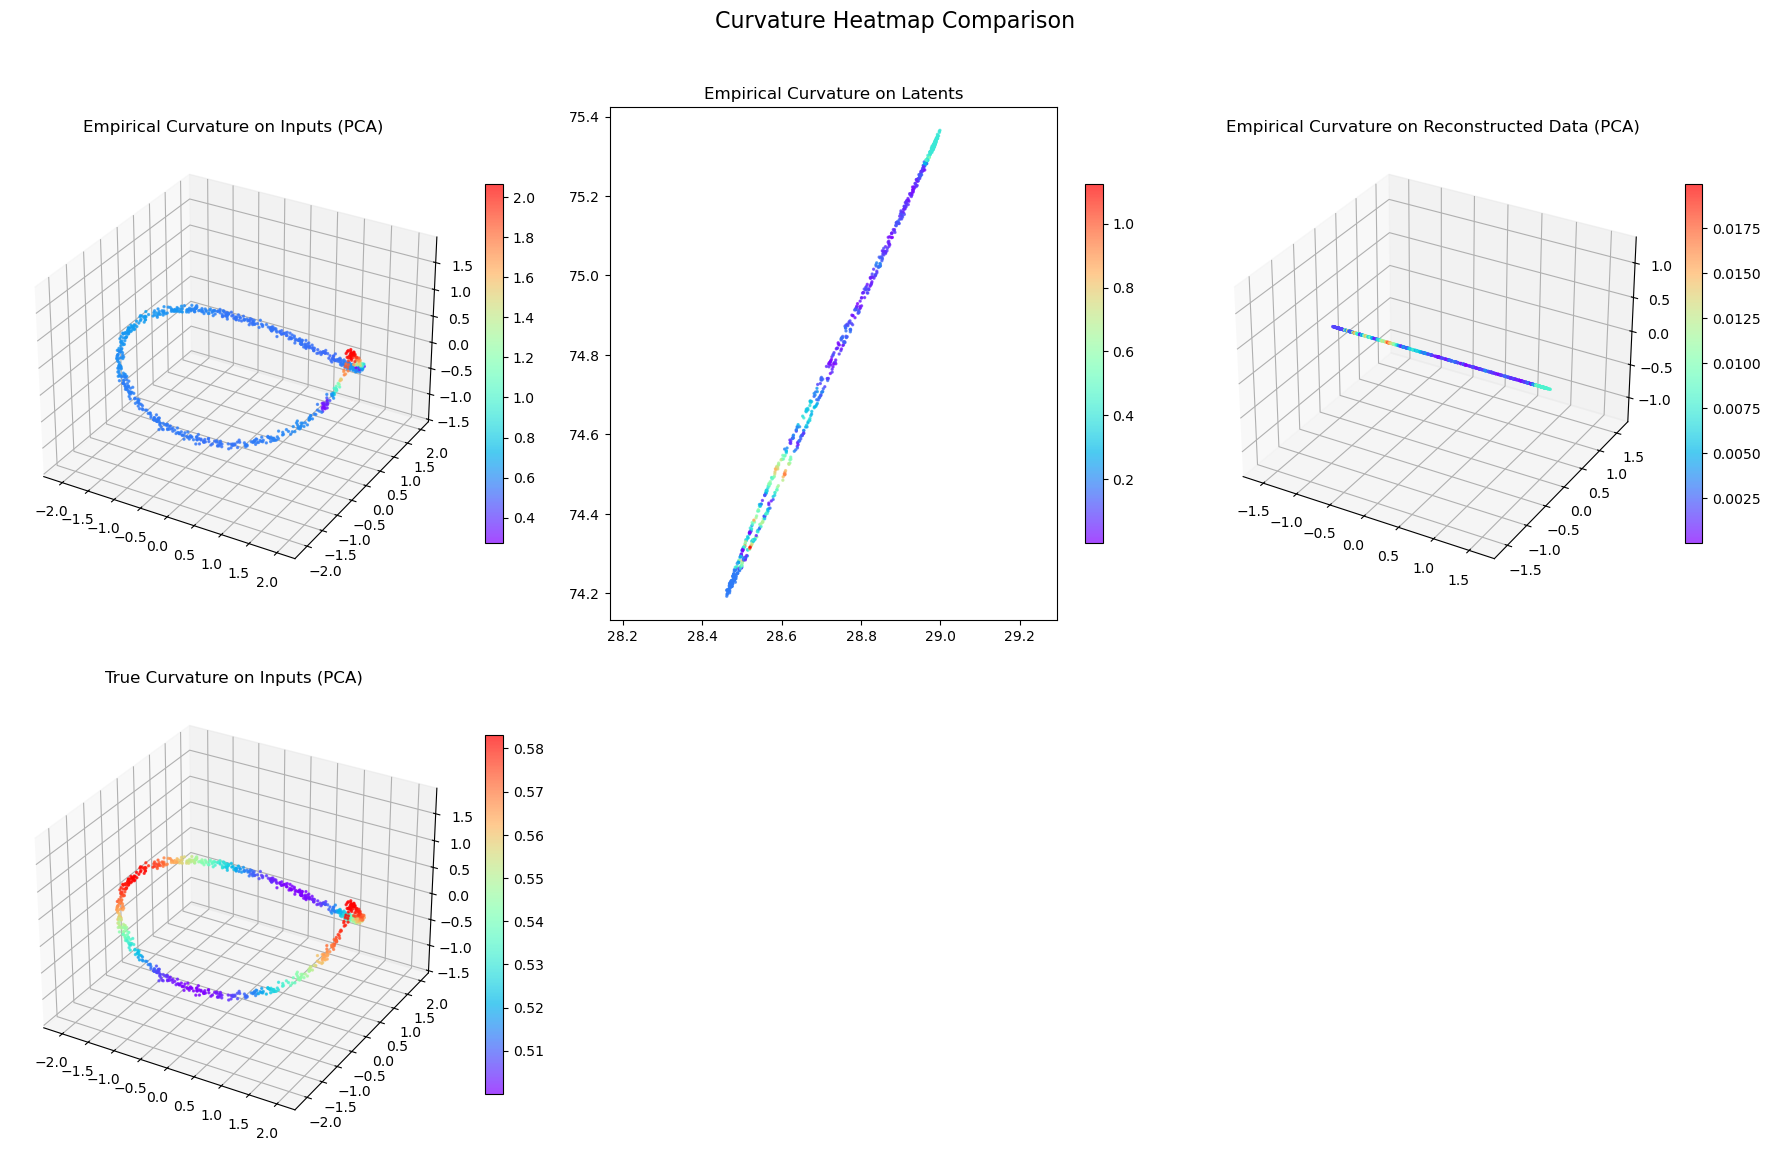

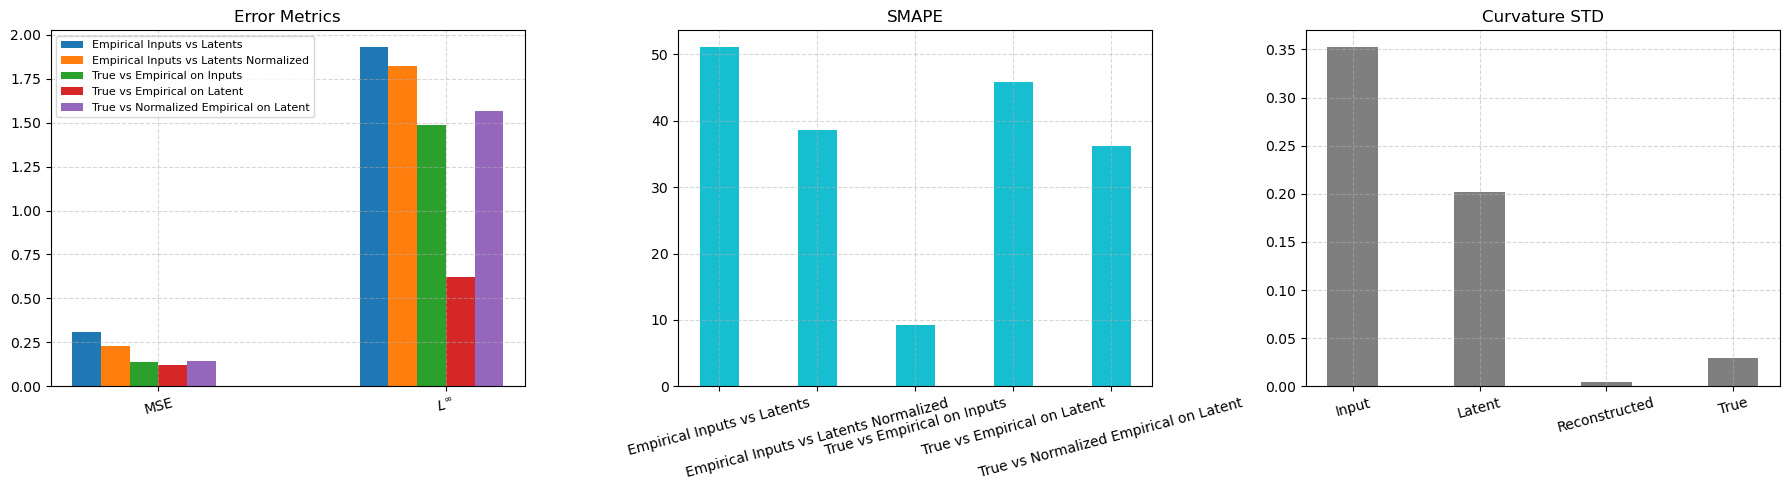

Execution time exp00_clelia_curve: 61.1238 seconds

Running exp01_clelia_curve. 
Description: wiggling_dim=4, embedding_dim=10, alpha=1, gamma=0, clelia_c=0.3, dim_topo_loss=1
--------------------------------------------------------------------------------------


KeyboardInterrupt: 

In [16]:
run_experiment(all_configs=all_configs)